# **Measure Object Distribution**

***Prior to this notebook, you should have already run through [2.0_quantification_setup](2.0_quantification_setup.ipynb).***

The `'methods_...'` notebooks included here in infer-subc Part 2: quantification will go over how each of the quantification methods (morphology, interactions, and distribution) are carried out. The notebooks will explain each step in the method and display the combined function at the end of the notebook.

### **Biological Relevance**
Organelle and cell volume distribution metrics are part of the organelle signature analysis. These metrics can provide information about the structual makeup of the cell robust to cell size.

**<span style="background-color: #ff0000aa">Text here, with quotes from other research done on organelle distribution and its importance. There is a lot of research on this relating to lysosomal fuctional localization and ER as well.</span>**

### **Distribution Measurements** 📐
The following morphological measurements are included:

- `object`: name to identify the object being measured

**<span style="background-color: #00812241">XY Distribution</span>**

- `XY_n_bins`: number of disjoint concentric bins that divide the 3D cell mask
- `XY_bins`: list of bin numbers
- `XY_mask_vox_cnt_perbin*`: number of voxels in the 3D cell mask per bin
- `XY_obj_vox_cnt_perbin*`: number of voxels of the 3D object per bin
- `XY_center_vox_cnt_perbin*`: number of voxels of the 3D centering object per bin
- `XY_n_pix_perbin*`: number of pixels per bin in the XY mask
- `XY_portion_pix_perbin`: the proportion of pixels in the XY mask per bin
- `XY_n_wedges`: number of wedges in each concentric bin
- `XY_wedges`: list of wedge numbers
- `XY_mask_vox_cnt_perwedge*`: number of voxels in the 3D cell mask per wedge
- `XY_obj_vox_cnt_perwedge*`: number of voxels of the 3D object per wedge
- `XY_center_vox_cnt_perwedge*`: number of voxels of the 3D centering object per wedge
- `XY_n_pix_perwedge*`: number of pixels per wedge in the XY mask
- `XY_portion_pix_perwedge`: the proportion of pixels in the XY mask per bin
- `XY_wedges_perbin`: list of wedges that have >0 pixels in the mask for all bins
- `XY_mask_vox_cnt_wedges_perbin*`: number of voxels in the 3D cell mask per wedge per bin
- `XY_obj_vox_cnt_wedges_perbin*`: number of voxels of the 3D object per wedge per bin
- `XY_center_vox_cnt_wedges_perbin*`: number of voxels of the 3D centering object per wedge per bin
- `XY_n_pix_wedges_perbin*`: number of pixels per wedge per bin in the XY mask
- `XY_mask_cv_perbin`: the coefficient of variance of the wedges within each bin for the mask
- `XY_obj_cv_perbin`: the coefficient of variance of the wedges within each bin for the object segmentation
- `XY_center_cv_perbin`: the coefficient of variance of the wedges within each bin for the centering object

**<span style="background-color: #00829c42">Z Distribution</span>**

- `Z_n_slices`: the number of z-slices in the raw image
- `Z_slices`: a numbered list representing each z-slice (first element of the list is 0)
- `Z_mask_vox_cnt`: number of voxels in the 3D cell mask per z-slice
- `Z_obj_vox_cnt`: number of voxels in the 3D object per z-slice
- `Z_center_vox_cnt`: number of voxels of the 3D centering object per z-slice
- `Z_height*`: the height of the raw image in microns
- `Z_mask_volume*`: the amount of cell mask volume in cubic mircons per z-slice 
- `Z_obj_volume*`: the amount of object volume in cubic mircons per z-slice 
- `Z_center_volume*`: the amount of centering object volume in cubic mircons per z-slice

###### *If scale is used, scaled measurements are added to the output.
###### **If there is no centering object, then centering object metrics will be omitted

-----

### 👣 **Summary of steps**  

🛠️ **BUILD FUNCTIONS STEP-BY-STEP**

**<span style="color: #008122;">XY Distribution</span>**

- **`STEP 1`** - Create 2D sum projections

- **`STEP 2`** - Measure distance from the center and edge using [centrosome](https://github.com/CellProfiler/centrosome)

- **`STEP 3`** - Create concetric bins and wedges from which to measure distribution

- **`STEP 4`** - Measure concetric measurement and zernike features

⚙️ **DEFINE AND TEST *`XY DISTRIBUTION`* FUNCTION**

- Define `get_XY_distribution` function
- Run `get_XY_distribution` function

**<span style="color: #00829c;">Z Distribution</span>**

- **`STEP 1`** - Sum voxels along the X and Y axes

- **`STEP 2`** - Summarize data per z slice using the bin format

⚙️ **DEFINE AND TEST *`Z DISTRIBUTION`* FUNCTION**

- Define `get_Z_distribution` function
- Run `get_Z_distribution` function

---------------------
## **IMPORTS AND LOAD IMAGE**
Details about the functions included in this subsection are outlined in the [`2.0_quantification_setup`](2.0_quantification_setup.ipynb) notebook. Please visit that notebook first if you are confused about any of the code included here.

In [125]:
from pathlib import Path
import os
import itertools
import seaborn as sns

import napari
from napari.utils.notebook_display import nbscreenshot

from infer_subc.core.file_io import (read_czi_image,
                                        import_inferred_organelle,
                                        list_image_files)

from infer_subc.core.img import *
from infer_subc.quantification.stats import *
from infer_subc.quantification.stats_helpers import *
from infer_subc.organelles import *

# allow for the display of all columns
pd.set_option('display.max_columns', None)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify the following information about your data: `raw_img_type`, `data_root_path`, `raw_data_path`, `seg_data_path`, and `quant_data_path`.

In [126]:
#### USER INPUT REQUIRED ###
raw_img_type = ".tiff"
data_root_path = Path(os.path.expanduser("~")) / "Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1"
raw_data_path = data_root_path / "raw"
seg_data_path = data_root_path / "seg"
quant_data_path = data_root_path / "quant"

#### &#x1F3C3; **Run code; no user input required**

In [127]:
# Create the output directory to save the segmentation outputs in.
if not Path.exists(quant_data_path):
    Path.mkdir(quant_data_path)
    print(f"making {quant_data_path}")

# Create a list of the file paths for each image in the input folder. Select test image path.
raw_img_file_list = list_image_files(raw_data_path,raw_img_type)
pd.set_option('display.max_colwidth', None)
pd.DataFrame({"Image Name":raw_img_file_list})

,Image Name
0,C:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_neuron_1\raw\20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome.tiff


#### &#x1F6D1; &#x270D; **User Input Required:**

Use the list above to specify which image you wish to analyze based on its index: `test_img_n`

In [128]:
#### USER INPUT REQUIRED ###
test_img_n = 0

#### &#x1F3C3; **Run code; no user input required**

In [129]:
# Read in the image and metadata as an ndarray and dictionary from the test image selected above. 
test_img_name = raw_img_file_list[test_img_n]
img_data,meta_dict = read_czi_image(test_img_name)

# Define some of the metadata features.
channel_names = meta_dict['name']
meta = meta_dict['metadata']['aicsimage']
scale = meta_dict['scale']
channel_axis = meta_dict['channel_axis']
file_path = meta_dict['file_name']

print("Metadata information")
print(f"File path: {file_path}")
for i in list(range(len(channel_names))):
    print(f"Channel {i} name: {channel_names[i]}")
print(f"Scale (ZYX): {scale}")
print(f"Channel axis: {channel_axis}")

Metadata information
File path: C:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_neuron_1\raw\20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome.tiff
Channel 0 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:0
Channel 1 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:1
Channel 2 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:2
Channel 3 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:3
Channel 4 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:4
Channel 5 name: 20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome :: Channel:5
Scale (ZYX): (0.410594, 0.079947, 0.079947)
Channel axis: 0


#### &#x1F6D1; &#x270D; **User Input Required:**

Specify the following information about the segmentation files: - `org_file_names`, `org_channels_ordered`, `regions_file_names`, `suffix_separator`, and `mask_name`.

In [130]:
#### USER INPUT REQUIRED ###
org_file_names = ["lyso", "mito", "golgi", "perox", "ER", "LD"]
org_channels_ordered = [3, 4, 2, 5, 1, 0]
regions_file_names = ["nuc", "cell"]
suffix_separator = "-"
mask_name = "cell"

#### &#x1F3C3; **Run code; no user input required**

In [131]:
# find file paths for segmentations
all_suffixes = org_file_names + regions_file_names
filez = find_segmentation_tiff_files(file_path, all_suffixes, seg_data_path, suffix_separator)

# read the segmentation and masks/regions files into memory
organelles = [read_tiff_image(filez[org]) for org in org_file_names]
regions = [] 
for m in regions_file_names:
    mfile = read_tiff_image(filez[m])
    regions.append(mfile)

# match the intensity channels to the segmentation files
intensities = [img_data[ch] for ch in org_channels_ordered]

# specifiy the mask image
m = regions_file_names.index(mask_name)
mask = regions[m]

# open viewer and add images
viewer = napari.Viewer()
for r, reg in enumerate(regions_file_names):
    viewer.add_image(regions[r],
                     scale=scale,
                     name=f"{reg} mask")

for o, org in enumerate(org_file_names):
    viewer.add_image(intensities[o],
                     scale=scale,
                     name=f"{org} intensity channel")
    viewer.add_labels(organelles[o],
                      scale=scale,
                      name=f"{org} segmentation")
viewer.grid.enabled = True
viewer.reset_view()

print("The following matching files were found and can now be viewed in Napari:")
filez


The following matching files were found and can now be viewed in Napari:


{'raw': WindowsPath('C:/Users/redre/Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1/raw/20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome.tiff'),
 'lyso': WindowsPath('C:/Users/redre/Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1/seg/20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome-lyso.tiff'),
 'mito': WindowsPath('C:/Users/redre/Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1/seg/20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome-mito.tiff'),
 'golgi': WindowsPath('C:/Users/redre/Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1/seg/20230727_C2-121_conditioned_well 4_cell 3_untreated_Linear unmixing_0_cmle.ome-golgi.tiff'),
 'perox': WindowsPath('C:/Users/redre/Documents/CohenLab/scohen_lab_repo/infer-subc/sample_data/example_neuron_1/seg/20230727_C2-121_conditioned_well 4_cell 3_untreated_Lin

-----
## **QUANTIFY DISTRIBUTION OF *one object type* FROM <INS>ONE CELL</INS>**

# ***PART 1️⃣: XY DISTRIBUTION***

### **`Step 1`** - Create 2D sum projections

&#x1F453; **FYI:** We will create a sum projection of the centering object, mask and object (e.g., organelle) we want to measure the distribution of. The mask and centering object will be important for creating the distribution "bins" that will span from the centering object to the cell periphery.

#### **`Step 1A`** - Collect and object (organelle), mask, and object segmentations

&#x1F453; **FYI:** The centering object is optional but recommended. Using the nucleus segmentation as the centering object creates bins that are biologically relevent. Also note that the name of the mask was set earlier in the notebook.

#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify which organelle you would like to examine in this analysis and which segmentation file should be used as the mask:

- `obj_seg_name`: the suffix of the object you would like to measure the distribution of; it should match one of the names included in the "org_file_names" variable above

- `center_obj_name`: The name of the segmentation you would like to be treated as the center of the cell; if not using a centering object set to *None*

In [132]:
#### USER INPUT REQUIRED ###
obj_seg_name = "golgi"
center_obj_name = "nuc"

#### &#x1F3C3; **Run code; no user input required**

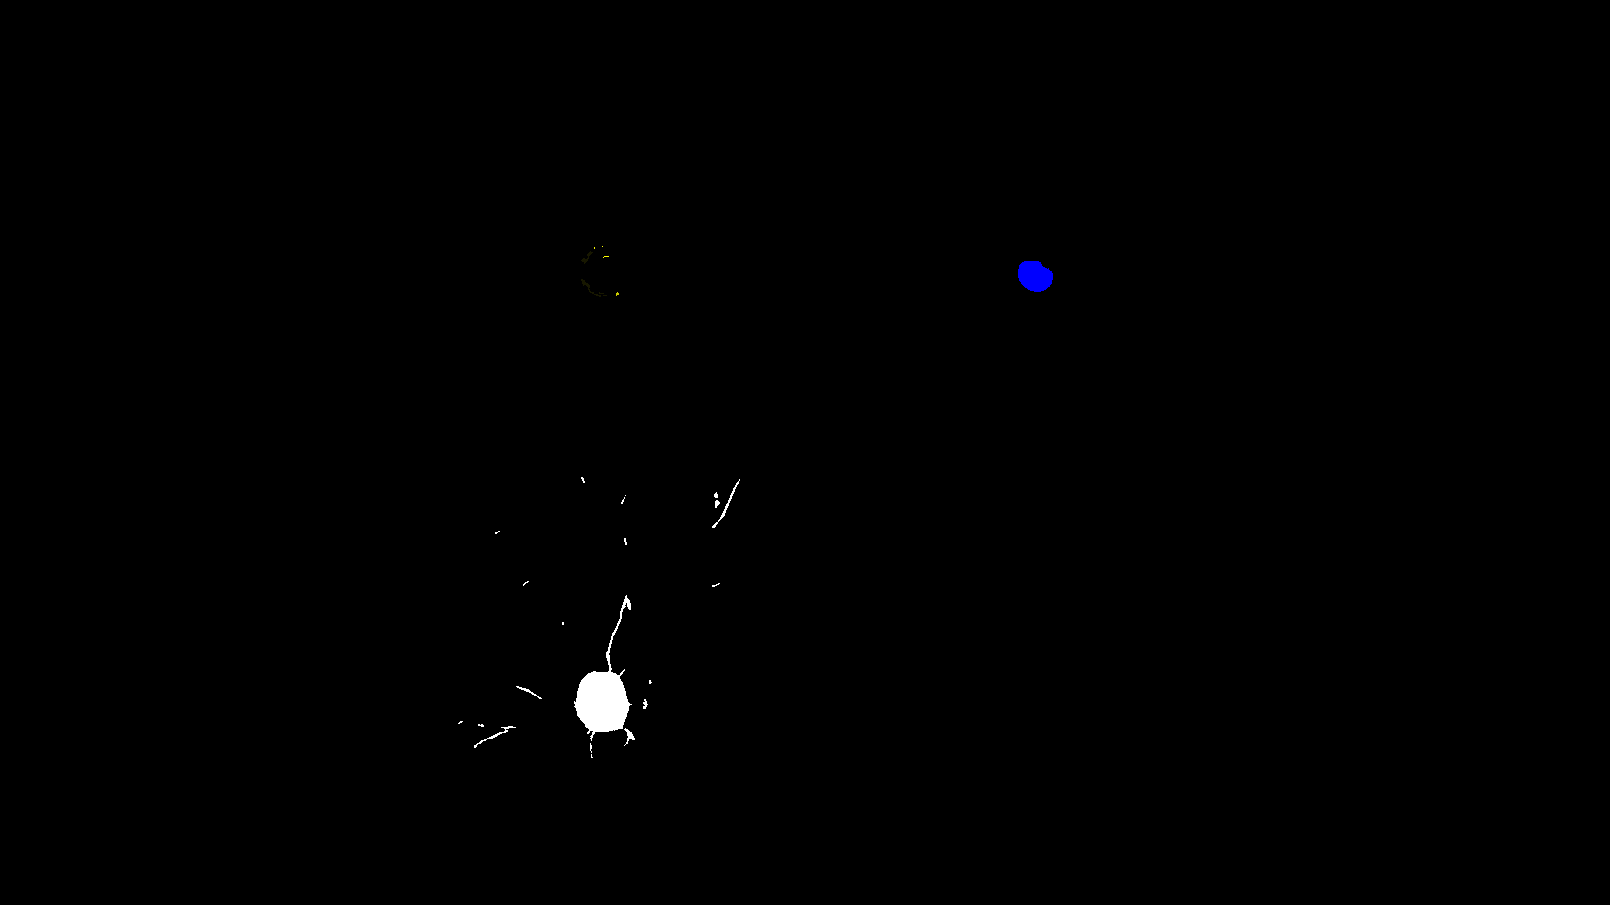

In [133]:
# establish segmentations that will be used throught the notebook
mask_seg = regions[regions_file_names.index(mask_name)]
if center_obj_name:
    center_obj_seg = regions[regions_file_names.index(center_obj_name)]
else:
    center_obj_seg = None
org_seg = organelles[org_file_names.index(obj_seg_name)]


# visualization
viewer.layers.clear()
viewer.add_image(mask_seg, colormap="gray", scale = scale)
if center_obj_name:
    viewer.add_image(center_obj_seg, colormap="blue", scale = scale)
viewer.add_image(org_seg, colormap="yellow", scale = scale)
viewer.reset_view()
viewer.grid.enabled = True

nbscreenshot(viewer, canvas_only=True)

###### **<span style="color: #FFFF00ff;">Yellow</span>**: Object Segmentation | **White**: Mask Segmentation
###### (If centering object is included) **<span style="color: #0000FFff;">Blue</span>**: Centering Object Segmentation

#### **`Step 1B`** - Make 2D sum projection of binary segmentations and visualize

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** In this step the `create_masked_sum_projection()` is defined and ran on all three segmentations we just collected in the previous step. The function simply sums the 3D input along the Z-axis. This creates a 2 dimensional *Sum Projection*.

> ***Sum projection (XY)***
>
> This type of sum projection adds together the voxel intensity at each XY position to produce a single XY plane representative of the entire Z intensity.
> Here, we will be creating sum projections of the binary segmentations, so the "intensity" is representative of the number of voxels at each XY position that are "True", or object.


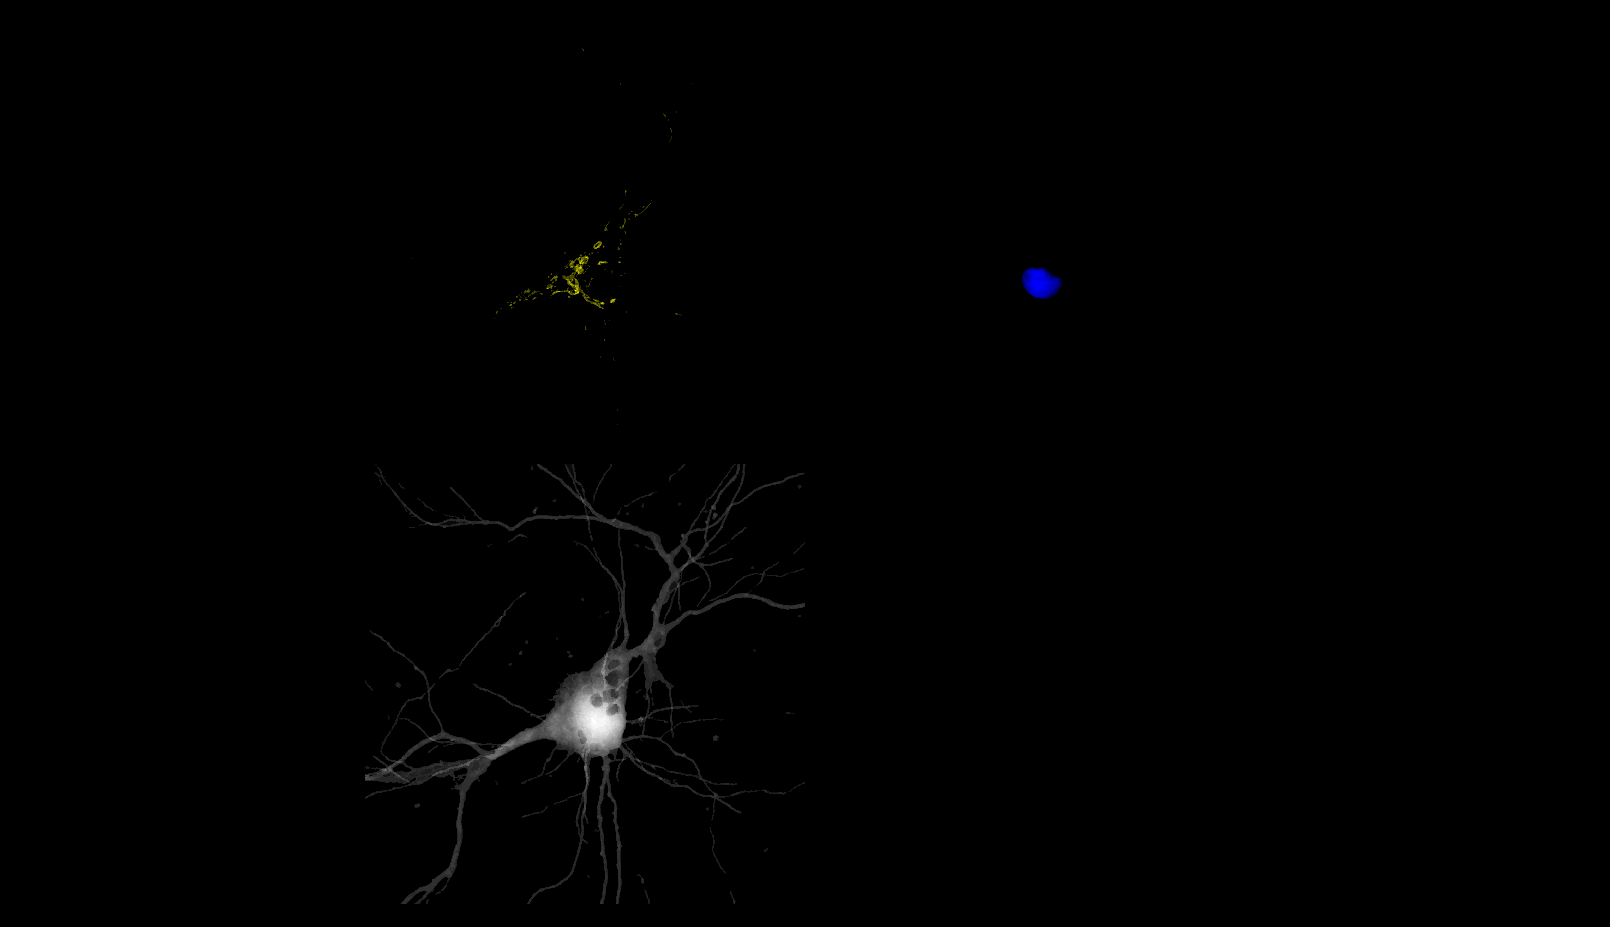

In [134]:
# define function

def _create_masked_sum_projection(img_in:np.ndarray, mask:Union[np.ndarray, None]=None, to_bool:bool=True) -> np.ndarray:
    """
    Parameters:
    ----------
    img_in:
        3D (ZYX) np.ndarray that will be summed along the Z axis
    mask:
        Optional - mask of the region you want to include in the final sum projection
    to_bool:
        True = input image is created in a boolean image before sum projection (useful for segmentation images where each object is coded as a unique ID number; like after skimage.segmentation.label())
        False = original input image is used for the sum projection
    """
    img_out = img_in.astype(bool) if to_bool else img_in
    if mask is not None:
        img_out = apply_mask(img_out, mask)
    
    return img_out.sum(axis=0)

# create projection masks

test_mask_proj = _create_masked_sum_projection(mask)
if center_obj_name:
    test_center_obj_proj = _create_masked_sum_projection(center_obj_seg, mask.astype(bool))
else:
    test_center_obj_proj = None
test_org_proj = _create_masked_sum_projection(org_seg, mask.astype(bool))

viewer.layers.clear()
viewer.add_image(test_mask_proj, colormap="gray")
if center_obj_name:
    viewer.add_image(test_center_obj_proj, colormap="blue")
viewer.add_image(test_org_proj, colormap="yellow")
viewer.reset_view()
viewer.grid.enabled = True
nbscreenshot(viewer, canvas_only=True)

###### **<span style="color: #FFFF00ff;">Yellow</span>**: Object Projection | **White**: Mask Projection
###### (If centering object is included) **<span style="color: #0000FFff;">Blue</span>**: Centering Object Projection

#### **`Step 2`** - Measure distance from the center and edge using [centrosome](https://github.com/CellProfiler/centrosome)

#### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** The `get_normalized_distance_and_mask()` function usually creates an array where distance is normalized from the centering object to the edge of the mask. In short, the center pixel is 0 and any pixel on the perimeter of the mask is 1. How the distance is calculated is based off of the existence of a centering object and user input specifications. The `get_normalized_distance_and_mask()` function has been modified to show intermediate results for comprehension. Specifically, the *d_to_edge* and *d_from_center* arrays are merged resulting in the final *normalized_distance* array.

> **Description of output from `get_normalized_distance_and_mask()`**
>
> <span style="color: #8d8d8dff;">*The following four objects compose the default output*</span>
>
> **normalized_distance**:
> Two-dimensional (YX) np.ndarray with intensity values representing the distance between the edge of the mask and the 
> centering object. Or just the distance from the edge of the mask object if a centering object is not given.
>
> **good_mask**:
> Essentially a copy of the mask; a (YX) np.ndarray used to bound the calculations for distance from the edge and distance from the center (if a centering object exists)
>
> **i_center**: 
> Two-dimensional (YX) np.ndarray in the shape of the good mask (pixels used when creating the bins later on), all pixels are valued...
> If center_objects *is not* None: the y coordinate of the centering object's centermost point\
> If center_objects *is* None: the y coordinate of the mask's innermost point (distance from the edge)
>
> **j_center**:
> Two-dimensional (YX) np.ndarray in the shape of the good mask (pixels used when creating the bins later on), all pixels are valued...
> If center_objects *is not* None: the x coordinate of the centering object's centermost point\
> If center_objects *is* None: the x coordinate of the mask's innermost point (distance from the edge)
>
> <span style="color: #8d8d8dff;">*The following two objects are optional output*</span>
>
> **d_to_edge**: 
> Two-dimensional (YX) np.ndarray with intensity values representing the distance of a pixel from the edge of the mask 
>
> **d_from_center**: 
> Two-dimensional (YX) np.ndarray with intensity values representing the distance of a pixel from either the edge of the 
> centering object (if center_on = False), or the centering object's centermost point (if center_on = True). However if there is
> no centering object, the array will consist of zeros.

Please specify the centering object behavior

- `center_on`: If set to *True* the distance from the **centermost point** of the centering object to the edge of the cell will be measured. If set to *False* the distance from the **edge** of the centering object to the edge of the cell will be measured. If you are not using a centering object, then this value will not be used. 


In [ ]:
#### USER INPUT REQUIRED ###
center_on = False

#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# Define function

def _get_normalized_distance_and_mask(labels: np.ndarray, 
                                      center_objects: Union[np.ndarray, None], 
                                      center_on: bool,
                                      intres: Union[bool, None] = False):
    """
    helper for radial distribution
    Parameters:
    ----------
    labels:
        2D (YX) np.ndarray - normally the result of a binary ZYX segmentation of the cell mask after a sum projection across the Z dimension
    center_object:
        2D (YX) np.ndarray - normally the result of a binary ZYX segmentation of the nucleus after a sum projection across the Z dimension.
        If no centering object is included, the center of the labels will be used.
    center_on:
        True = the center of the centering object will be used as the starting point to calculate the distance from the center
        False = the edge of the centering object will be used as the starting point to calculate the distance from the center
    
    Output:
    ----------
    normalized_distance:
        2D (YX) np.ndarray with intensity values representing the distance between the edge of the "labels" and the centering object.
        More specifically for the centering object, either the edge or the centermost point is used, depending on the center_on
        parameter. If there is no centering object, the values will represent the distance from the edge of the "labels" object.
    good_mask:
        mask of the areas that were included in the normalized_distance output
    i_center: If center_objects *is not* None: i coordinate of the centermost point of the centering object
              If center_objects *is* None: the i coordinate of the innermost (distance from the edge) point of the "labels" input
    j_center: If center_objects *is not* None: j coordinate of the centermost point of the centering object
              If center_objects *is* None: the j coordinate of the innermost (distance from the edge) point of the "labels" input
    d_to_edge:
        2D (YX) np.ndarray with intensity values representing the distance from the edge of the "labels" object.
    d_from_center:
        2D (YX) np.ndarray with intensity values representing the distance from the centermost point of the centering object,
        or the edge of the centering object (depending on the value of center_on).

    """

    d_to_edge = centrosome.cpmorphology.distance_to_edge(labels)

    if center_objects is not None:
        center_labels = label(center_objects)
        pixel_counts = centrosome.cpmorphology.fixup_scipy_ndimage_result(ndi_sum(np.ones(center_labels.shape), 
                                                                                  center_labels, 
                                                                                  np.arange(1, np.max(center_labels) + 1, dtype=np.int32)))
        good = pixel_counts > 0
        i, j = (centrosome.cpmorphology.centers_of_labels(center_labels) + 0.5).astype(int)
        ig = i[good]
        jg = j[good]
        lg = np.arange(1, len(i) + 1)[good]
        
        if center_on:  # Reduce the propagation labels to the centers of the centering objects
            center_labels = np.zeros(center_labels.shape, int)
            center_labels[ig, jg] = lg

        cl, d_from_center = centrosome.propagate.propagate(np.zeros(center_labels.shape), center_labels, labels != 0, 1)
        cl[labels == 0] = 0

        missing_mask = (labels != 0) & (cl == 0)
        missing_labels = np.unique(labels[missing_mask])
        
        if len(missing_labels):
            print("how did we have missing labels?")
            all_centers = centrosome.cpmorphology.centers_of_labels(labels)
            missing_i_centers, missing_j_centers = all_centers[:, missing_labels-1]
            di = missing_i_centers[:, np.newaxis] - ig[np.newaxis, :]
            dj = missing_j_centers[:, np.newaxis] - jg[np.newaxis, :]
            missing_best = lg[np.argsort(di * di + dj * dj)[:, 0]]
            best = np.zeros(np.max(labels) + 1, int)
            best[missing_labels] = missing_best
            cl[missing_mask] = best[labels[missing_mask]]

            iii, jjj = np.mgrid[0 : labels.shape[0], 0 : labels.shape[1]]
            di = iii[missing_mask] - i[cl[missing_mask] - 1]
            dj = jjj[missing_mask] - j[cl[missing_mask] - 1]
            d_from_center[missing_mask] = np.sqrt(di * di + dj * dj)

        good_mask = cl > 0
            
    else:
        # i, j = centrosome.cpmorphology.maximum_position_of_labels(d_to_edge, labels, [1])
        i, j = centrosome.cpmorphology.maximum_position_of_labels(d_to_edge, labels, [1])
        center_labels = np.zeros(labels.shape, int)
        center_labels[i, j] = labels[i, j]
        colors = centrosome.cpmorphology.color_labels(labels)
        ncolors = np.max(colors)
        d_from_center = np.zeros(labels.shape)
        cl = np.zeros(labels.shape, int)

        for color in range(1, ncolors + 1):
            mask = colors == color
            # There is no Z height if we literally have flattened the image
            l, d = centrosome.propagate.propagate( np.zeros(center_labels.shape), center_labels, mask, 1)
            d_from_center[mask] = d[mask]
            cl[mask] = l[mask]

        good_mask = cl > 0

    i_center = np.zeros(cl.shape)
    i_center[good_mask] = i[cl[good_mask] - 1]

    j_center = np.zeros(cl.shape)
    j_center[good_mask] = j[cl[good_mask] - 1]

    normalized_distance = np.zeros(labels.shape)
    total_distance = d_from_center + d_to_edge
    normalized_distance[good_mask] = d_from_center[good_mask] / (total_distance[good_mask] + 0.001)
    
    # include d_to_edge and d_from_center?
    if intres:
        return normalized_distance, good_mask, i_center, j_center, d_to_edge, d_from_center
    else:
        return normalized_distance, good_mask, i_center, j_center

# create binary arrays, if this does not work, it assumes there is no center object
center_objects = test_center_obj_proj>0 if test_center_obj_proj is not None else None
mask = (test_mask_proj>0).astype(np.uint16)

# collect output of get_normalized_distance_and_mask() function
(test_normalized_distance,
 test_good_mask, test_i_center,
 test_j_center, test_d_to_edge,
 test_d_from_center) = _get_normalized_distance_and_mask(labels=mask,
                                                         center_objects=center_objects,
                                                         center_on=center_on,
                                                         intres=True)

# print the y,x coordinates of the "center" (depending on user specifications)
print(f"The i,j image coordinates are {int(np.unique(test_i_center)[1]),int(np.unique(test_j_center)[1])}")

# visualization
viewer.layers.clear()
viewer.add_image(test_d_to_edge*255, colormap='gist_earth', name = "dist to edge")
viewer.add_image(test_d_from_center*255, colormap='gist_earth', name = "dist from center")
viewer.add_image(test_normalized_distance*255, colormap = 'gist_earth', name = "normalized dist")

viewer.reset_view()
viewer.grid.enabled = True
nbscreenshot(viewer, canvas_only=True)

# np.array_equal(test_normalized_distance, test_normalized_distance_a), np.array_equal(test_good_mask, test_good_mask_a), np.array_equal(test_i_center, test_i_center_a), np.array_equal(test_j_center, test_j_center_a)

###### Images in order: Normalized Distance, Distance from Center, Distance from edge (values in image range from 0 to 255 for visualization)

### **`Step 3`** - Create concetric bins and wedges from which to measure distribution

&#x1F453; **FYI:** The concentric rings (based on the normalized_distribution output above) will be our main "bins" to measure from. The wedges will divide each bin equally into 8 parts radially (think pie slices out from the center of the centering object).

> ###### 📝 **The logic was borrowed from [CellProfiler](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.2.5/modules/measurement.html?highlight=distribution#module-cellprofiler.modules.measureobjectintensitydistribution), but alorithm somewhate simplified by making assumpitions of doing all estimates over a single cellmask (single cell).   Most of the code should be capable of performing the more complicated multi-object versions as [CellProfiler](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.2.5/modules/measurement.html?highlight=distribution#module-cellprofiler.modules.measureobjectintensitydistribution) does.  Although this functionality is untested the source code was left in this more complex format in case it might be updated for this functionality in the future**

#### **`Step 3A`** - Create concetric bins

#### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** The combination of the existence of a centering object, and the parameters `center_on` and `test_keep_center_as_bin` allow 4 options in terms of concentric bin creation. 
> **No centering object**:
> In the case that a centering object is not given, n concetric bins will be created around the innermost point of the mask.
>
> **Centering object exists**:
>
> if center_on and test_keep_center_as_bin are both set to = **True**, then n bins will be created around the centermost point of
> the centering object (this does **not** mean that the first bin will be in the shape of the centering object)
>
> if center_on = **False** and test_keep_center_as_bin = **True**, then n-1 bins will be created around the centering object,
> and the first bin will be in the shape of the centering object
>
> if center_on and test_keep_center_as_bin are both set to = **False**, then n bins will be created around the centering object,
> and no distribution quantification will be done in the centering object.

⚠️ If center_on is set to **True**, It is **not** recommended for test_keep_center_as_bin to be set to **False** if there exists a centering object. In this case it would be more plausible for center_on to be **False** that way quantification can be done around the centering object.

⚠️ If at any point the `test_keep_center_as_bin` parameter is changed after being ran, please run step 2 again before running step 3 so that the correct "good_mask" is generated

- `bin_count`: number of bins to divide the mask into when quantifying distributiom

- `keep_center_as_bin`: whether or not to include the centering object area when creating the bins

In [ ]:
#### USER INPUT REQUIRED ###
test_bin_count = 5
test_keep_center_as_bin = True

#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# Checker
if center_obj_name:
    if center_on and not test_keep_center_as_bin:
        print("center_on = True, test_keep_center_as_bin = False, with the existence of a centering object" \
        " may not yield expected results")
else:
    test_keep_center_as_bin = True
    center_on = True
        

# create bin mask array
viewer.layers.clear()

if test_keep_center_as_bin:
    if center_on:
        bin_array = (test_normalized_distance * test_bin_count).astype(int)
    else:
        bin_array= ((test_normalized_distance * (test_bin_count-1))+1).astype(int)
        bin_array[center_objects]=0
        bin_array[~test_good_mask]=0       
else:
    test_good_mask[center_objects]=0
    if center_on:
        test_normalized_distance[test_good_mask] = (test_normalized_distance[test_good_mask] - test_normalized_distance[test_good_mask].min())/(test_normalized_distance[test_good_mask].max() - test_normalized_distance[test_good_mask].min())
    bin_array = (test_normalized_distance * test_bin_count).astype(int)
        
bin_array[bin_array > test_bin_count] = test_bin_count

# visualization
bin_array_vis = bin_array + test_good_mask
viewer.add_image(bin_array_vis, colormap = "gnuplot2")
viewer.reset_view()
nbscreenshot(viewer, canvas_only=True)

### **`Step 3B`** - Create radial wedges

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** Radial wedges split the concetric bins into 8 sections; in the same fashion that a pie would but cut into 8 slices. This allows for the distribution within bins to be measured as well. The radial wedges have the origin i,j (in y,x image coordinates), thus the existence of the centering object affects the origin point of the radial wedges.

In [ ]:
# getting radial index for each pixel to create 8 wedges from center of centering object
test_i, test_j = np.mgrid[0 : test_mask_proj.shape[0], 0 : test_mask_proj.shape[1]] # intensity gradients of pixels in X (top to bottom) and then Y (left to right)
test_imask = test_i[test_good_mask] > test_i_center[test_good_mask]
test_jmask = test_j[test_good_mask] > test_j_center[test_good_mask]
test_absmask = abs(test_i[test_good_mask] - test_i_center[test_good_mask]) > abs(test_j[test_good_mask] - test_j_center[test_good_mask])
test_radial_index = (test_imask.astype(int) + test_jmask.astype(int) * 2 + test_absmask.astype(int) * 4)

# 2dim representation of radial indexes
test_radial_index_vis = np.zeros_like(test_good_mask, dtype=int)
test_radial_index_vis[test_good_mask] = test_radial_index

# visualization w/ colorblind palette

colors = sns.color_palette(palette="colorblind", n_colors=test_bin_count).as_hex()

viewer.layers.clear()
viewer.grid.enabled = False

for i in np.arange(test_bin_count):
    bin = bin_array==i
    viewer.add_image(apply_mask(test_good_mask + test_radial_index_vis,bin),
                     name=f"bin {i}",
                     blending="additive",
                     colormap=colors[i])

viewer.reset_view()
nbscreenshot(viewer, canvas_only=True)

### **`Step 4`** - Measure concetric measurement and zernike features

#### **`Step 4A`** - Collect conectric distribution measurements 

&#x1F453; **FYI:** Within each concetric bin, both scaled and unscaled features of the cell will be measured and stored in table format. The structure of the bins depend on the user specifications selected before this step. This step defines the `get_concentric_distribution()` function which composes one half of the `get_XY_distribution()`. See the doc strings within the function in the following cell for more detailed definitions of the table output.

#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# extra annotation preserved 

def _get_concentric_distribution(
        mask_proj: np.ndarray,
        centering_proj: np.ndarray,
        obj_proj: np.ndarray,
        obj_name: str,
        bin_count: int,
        center_on: bool = False,
        keep_center_as_bin: bool = True,
        scale: Union[tuple, None]=None):
    """
    Based on CellProfiler's measureobjectintensitydistribution. Measure the distribution of segmented objects within a masked area. 
    In our case, we will usually utilize this function to measure the amount of an organelle within the cell.
    Radial bins are created out from a center point, usually the nucleus edge.

    
    Parameters
    ------------
    mask_proj: np.ndarray
        a sum projection of the region you want to measure the distribution from where the "intensity" value of each pixel is equal 
        to the number of z slices where the binary cell mask is True
    centering_proj: np.ndarray
        a sum projection of the object you want to use as the center of the distribution where the "intensity" value of each pixel is 
        equal to the number of z slices where the binary nucleus mask is True
    obj_proj: np.ndarray,
        a sum projection of the stuff you want to measure where the "intensity" value of each pixel is equal to the number of z slices 
        where the binary organelle mask is True (for a segmented image) or the total intensity at that point (for a gray scale image)
    obj_name: str,
        the name or nickname of your object being measured; used for labeling columns in the dataframe
    bin_count: int,
        the number of concentric rings, or "bins", to create within the mask
    center_on: bool = False,
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    keep_center_as_bin: bool = True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins
    scale: Union[tuple, None]=None
        a tuple of floats representing the real-world dimensions for each image dimension (ZYX)
        

    Measurements
    ------------
    If scale is used, "vox_cnt" is replaced by "vol" and "n_pix_ is replaced by "area" in the title below.

    object: the nickname of what is being measured (e.g., golgi, golgiXER, ER_img)
    XY_n_bins: number of bins
    XY_bins: list of bin number
    XY_mask_vox_cnt_perbin: number of voxels in the 3D cell mask per bin
    XY_obj_vox_cnt_perbin: number of voxels of the 3D object per bin
    XY_center_vox_cnt_perbin: number of voxels of the 3D centering object per bin
    XY_n_pix_perbin: number of pixels per bin in the XY mask
    XY_portion_pix_perbin: the portion of pixels in the XY mask per bin
    XY_n_wedges: number of wedges
    XY_wedges: list of wedge numbers
    XY_mask_vox_cnt_perwedge: number of voxels in the 3D cell mask per wedge
    XY_obj_vox_cnt_perwedge: number of voxels of the 3D object per wedge
    XY_center_vox_cnt_perwedge: number of voxels of the 3D centering object per wedge
    XY_n_pix_perwedge: number of pixels per wedge in the XY mask
    XY_portion_pix_perwedge: the portion of pixels in the XY mask per bin
    XY_wedges_perbin: list of wedges that have >0 pixels in the mask for all bins
    XY_mask_vox_cnt_wedges_perbin: number of voxels in the 3D cell mask per wedge per bin
    XY_obj_vox_cnt_wedges_perbin:number of voxels of the 3D object per wedge per bin
    XY_center_vox_cnt_wedges_perbin: number of voxels of the 3D centering object per wedge per bin
    XY_n_pix_wedges_perbin: number of pixels per wedge per bin in the XY mask
    XY_mask_cv_perbin: the coefficient of variance of the wedges within each bin for the mask
    XY_obj_cv_perbin: the coefficient of variance of the wedges within each bin for the object segmentation
    XY_center_cv_perbin: the coefficient of variance of the wedges within each bin for the centering object

    
    Returns
    -------------
    tab: (pd.DataFrame) table of measurements of the object distribution
    bin_array: (np.ndarray) mask of the concentric rings to measure distribution from
    wedge_array: (np.ndarray) mask of the wedges (pie slices) that divide each bin into 8 parts
    """
    # other parameters that will stay constant
    nobjects = 1

    # create binary arrays
    if centering_proj is not None:
        center_objects = centering_proj>0
    else:
        center_objects = None
    mask = (mask_proj>0).astype(np.uint16)


    ################   ################
    ## compute distances and make bins and wedges masks
    ################   ################
    # created normalized distances
    normalized_distance, good_mask, i_center, j_center = get_normalized_distance_and_mask(labels=mask, center_objects=center_objects, center_on=center_on)
    if normalized_distance is None:
        print('normalized_distance returned wrong')

    # create bin mask array
    
    if center_objects is None:
        keep_center_as_bin = True
        center_on = True

    if keep_center_as_bin:
        if center_on:
            bin_array = (normalized_distance * bin_count).astype(int)
        else:
            bin_array= ((normalized_distance * (bin_count-1))+1).astype(int)
            bin_array[center_objects]=0
            bin_array[~good_mask]=0
    else:
        good_mask[center_objects]=0
        if center_on:
            normalized_distance[good_mask] = (normalized_distance[good_mask] - normalized_distance[good_mask].min())/(normalized_distance[good_mask].max() - normalized_distance[good_mask].min())
        bin_array = (normalized_distance * bin_count).astype(int)
            
    bin_array[bin_array > bin_count] = bin_count
    
    # create wedges mask array
    i, j = np.mgrid[0 : mask.shape[0], 0 : mask.shape[1]]
    imask = i[good_mask] > i_center[good_mask]
    jmask = j[good_mask] > j_center[good_mask]
    absmask = abs(i[good_mask] - i_center[good_mask]) > abs(j[good_mask] - j_center[good_mask])
    radial_index = (imask.astype(int) + jmask.astype(int) * 2 + absmask.astype(int) * 4)

    wedge_array = np.zeros_like(good_mask, dtype=int)
    wedge_array[good_mask] = radial_index
    

    ################   ################
    ## get histograms
    ################   ################

    # number of pixels in the good mask
    ngood_pixels = np.sum(good_mask)

    good_labels = mask[good_mask]

    # whole cell bin and wedge measurements
    mask_arrays = [bin_array, wedge_array]
    sections = [bin_count, 8]
    types = ['bin', 'wedge']

    met_dict = {}

    for array, num, name in zip(mask_arrays, sections, types):
        labels_and_bins = (good_labels - 1, array[good_mask])

        # get count of voxels in each bin from the following images
        met_dict[f"XY_mask_vox_cnt_per{name}"] = [coo_matrix((mask_proj[good_mask], labels_and_bins), shape=(nobjects, num)).toarray().squeeze().tolist()]
        met_dict[f"XY_obj_vox_cnt_per{name}"] = [coo_matrix((obj_proj[good_mask], labels_and_bins), shape=(nobjects, num)).toarray().squeeze().tolist()]
        if center_objects is not None:
            met_dict[f"XY_center_vox_cnt_per{name}"] = [coo_matrix((centering_proj[good_mask], labels_and_bins), shape=(nobjects, num)).toarray().squeeze().tolist()]

        # same concept, but with an empty array to calculate the number of pixels per bin
        n_pixels = [coo_matrix((np.ones(ngood_pixels), labels_and_bins), (nobjects, num)).toarray().squeeze().tolist()]
        met_dict[f"XY_n_pix_per{name}"] = n_pixels

        # total pixels in the mask
        total_pixels = np.sum(n_pixels, 1)
        total_repeated = np.dstack([total_pixels] * (num))[0]

        # get the proportion of pixels in each bin (*100 to get percentage of cell pixels per bin)
        met_dict[f"XY_portion_pix_per{name}"] = [(n_pixels / total_repeated).squeeze().tolist()]


    # per wedge per bin measurements
    bin_names =[]
    cv_mask = []
    cv_obj = []
    if center_objects is not None:
        cv_center = []
    mask_wedge_perbin = []
    obj_wedge_perbin = []
    if center_objects is not None:
        center_wedge_perbin = []
    pxl_cnt_wedge_perbin = []
    wedges_perbin = []

    for bin in range(bin_count):
        bin_mask = good_mask & (bin_array == bin) # selecting the bin as a mask
        bin_pixels = np.sum(bin_mask) # number of pixels in this bin for downstream calculations

        bin_labels = mask[bin_mask] # selecting portion of the cellmask within this bin

        bin_radial_index = radial_index[bin_array[good_mask] == bin] # selecting the portion of the wedges associated to this bin
        labels_and_radii = (bin_labels - 1, bin_radial_index) # (i,j) for coo_matrix function taking into account the 8 wedges within this bin

        # repeating the calculations above using the wedges instead of the bins
        radial_counts_mask = coo_matrix((mask_proj[bin_mask], labels_and_radii), (nobjects, 8) ).toarray() # amount of cell mask voxels per wedge in this bin
        radial_counts_obj = coo_matrix((obj_proj[bin_mask], labels_and_radii), (nobjects, 8)).toarray() # amount of object voxels per wedges in this bin
        if center_objects is not None:
            radial_counts_center = coo_matrix((centering_proj[bin_mask], labels_and_radii), (nobjects, 8)).toarray() # amount of centering object voxels per wedges in this bin
        pixel_count = coo_matrix((np.ones(bin_pixels), labels_and_radii), (nobjects, 8)).toarray()

        # safe gaurd against one of the wedges having an area of 0
        # np.ma.masked_array - "Masked values of True exclude the corresponding element from any computation."
        n_mask = pixel_count == 0
        radial_counts = [radial_counts_mask, radial_counts_obj]
        if center_objects is not None:
            radial_counts += [radial_counts_center]
        radial_cvs = []
        for count in radial_counts:
            radial_norm = np.ma.masked_array(count / pixel_count, n_mask)
            radial_cv = np.std(radial_norm, 1) / np.mean(radial_norm, 1)
            radial_cv[np.sum(~n_mask, 1) == 0] = 0
            radial_cv.mask = np.sum(~n_mask, 1) == 0
            radial_cvs.append(radial_cv)

        bin_name = bin + 1 if bin > 0 else 1
        wedges_perbin_name = np.ma.masked_array([it+1 for it in range(8)])

        bin_names.append(bin_name)
        cv_mask.append(float(np.mean(radial_cvs[0]))) #convert to float to make importing from csv more straightforward
        cv_obj.append(float(np.mean(radial_cvs[1])))
        if center_objects is not None:
            cv_center.append(float(np.mean(radial_cvs[2])))
        mask_wedge_perbin.append(radial_counts[0].squeeze().tolist())
        obj_wedge_perbin.append(radial_counts[1].squeeze().tolist())
        if center_objects is not None:
            center_wedge_perbin.append(radial_counts[2].squeeze().tolist())
        pxl_cnt_wedge_perbin.append(pixel_count.squeeze().tolist())
        wedges_perbin.append(wedges_perbin_name.data.squeeze().tolist())
    

    ################   ################
    ## create data table and account for scale
    ################   ################
    met_dict_1 = {'object': obj_name,
                    'XY_n_bins': bin_count,
                    'XY_bins': [bin_names]}
    met_dict_2 = dict(list(met_dict.items())[:5])
    met_dict_3 = {'XY_n_wedges': 8,
                    'XY_wedges': str([it+1 for it in range(8)])}
    met_dict_4 = dict(list(met_dict.items())[5:])
    if center_objects is not None:
        met_dict_5 = {'XY_wedges_perbin': [wedges_perbin],
                    'XY_mask_vox_cnt_wedges_perbin':[mask_wedge_perbin],
                    'XY_obj_vox_cnt_wedges_perbin':[obj_wedge_perbin],
                    'XY_center_vox_cnt_wedges_perbin': [center_wedge_perbin],
                    'XY_n_pix_wedges_perbin': [pxl_cnt_wedge_perbin],
                    'XY_mask_cv_perbin':[cv_mask],
                    'XY_obj_cv_perbin':[cv_obj],
                    'XY_center_cv_perbin': [cv_center]}
    else:
        met_dict_5 = {'XY_wedges_perbin': [wedges_perbin],
                    'XY_mask_vox_cnt_wedges_perbin':[mask_wedge_perbin],
                    'XY_obj_vox_cnt_wedges_perbin':[obj_wedge_perbin],
                    'XY_n_pix_wedges_perbin': [pxl_cnt_wedge_perbin],
                    'XY_mask_cv_perbin':[cv_mask],
                    'XY_obj_cv_perbin':[cv_obj]}

    dict_combined = dict(itertools.chain(met_dict_1.items(), met_dict_2.items(), met_dict_3.items(), met_dict_4.items(), met_dict_5.items()))
    tab = pd.DataFrame(dict_combined)

    # account for scale
    if scale is not None:
        round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
        tab.insert(loc=1, column="scale", value=f"{round_scale}")
        
        # measurements affected by scale
        if center_objects is not None:
            vol_mets = ['XY_mask_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin', 'XY_center_vox_cnt_perbin', 'XY_mask_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge',
                    'XY_center_vox_cnt_perwedge', 'XY_mask_vox_cnt_wedges_perbin', 'XY_obj_vox_cnt_wedges_perbin', 'XY_center_vox_cnt_wedges_perbin']
        else:
            vol_mets = ['XY_mask_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin', 'XY_mask_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge',
                    'XY_mask_vox_cnt_wedges_perbin', 'XY_obj_vox_cnt_wedges_perbin']
        area_mets = ['XY_n_pix_perbin', 'XY_n_pix_perwedge', 'XY_n_pix_wedges_perbin']

        for met in vol_mets:
            tab[met.replace('_vox_cnt_', "_vol_")] = [(np.float_(tab[met][0]) * np.prod(scale)).squeeze().tolist()]
        for met in area_mets:
            tab[met.replace('_n_pix_', "_area_")] = [(np.float_(tab[met][0]) * np.prod(scale[1:])).squeeze().tolist()]

    else: 
        tab.insert(loc=2, column="scale", value=f"{tuple(np.ones(3))}")

    return tab, bin_array, wedge_array

test_stats_tab, test_bin_indexes, test_wedge_indexes = _get_concentric_distribution(mask_proj=test_mask_proj, 
                                                                                            centering_proj=test_center_obj_proj, 
                                                                                            obj_proj=test_org_proj, 
                                                                                            obj_name=obj_seg_name, 
                                                                                            scale=scale,
                                                                                            bin_count=test_bin_count, 
                                                                                            center_on=center_on,
                                                                                            keep_center_as_bin=test_keep_center_as_bin)

# table for concetric distribution function
test_stats_tab

In [ ]:
# test_stats_tab_a.to_csv("E:/Dissertation/Dissertation figures/Organelle distribution example output/20250214_test-lyso_XY-dist.csv")

In [ ]:
# # visualization of organelles within bins and wedges 
# fourdim_bins = []
# for bin in range(test_bin_count):
#     bin_image_2d = test_bin_indexes_a == bin
#     bin_image_2d = apply_mask(bin_image_2d, test_good_mask)
#     bin_image_4d = np.tile(bin_image_2d, (raw_img_data.shape[0], raw_img_data.shape[1],1,1))
#     fourdim_bins.append(bin_image_4d)
# fourdim_bins = np.array(fourdim_bins)

# viewer.layers.clear()

# colors = ["blue","green","yellow","bop orange","gray"]
# for bin in range(test_bin_count):
#     viewer.add_image(raw_img_data[3] * fourdim_bins[bin][5],
#                         colormap=colors[bin],
#                         blending="additive",
#                         scale=scale,contrast_limits=([0, 10000]),
#                         rotate = (5, 5, 0))
# viewer.grid.enabled=False
# viewer.reset_view()
# nbscreenshot(viewer, canvas_only=True)

#### **`Step 4B` - Collect measurement about the distribution the organelles within each bin using zernike features**

#### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** The Zernike features characterize the distribution of intensity across the object. For instance, Zernike 1,1 has a high value if the intensity is low on one side of the object and high on the other. The zernike magnitudes feature records the rotationally invariant degree magnitude of the moment and the zernike phase feature gives the moment’s orientation. For more information on Zernike Polynomials click [here](https://en.wikipedia.org/wiki/Zernike_polynomials).

> ###### The logic was borrowed from [CellProfiler](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.2.5/modules/measurement.html?highlight=distribution#module-cellprofiler.modules.measureobjectintensitydistribution), but alorithm greatly simplified by making assumpitions of doing all estimates over a single cellmask (single cell)

Please specify the following

- `zernike_degree`: number of degrees to use for calculating zernike features; if you wish to skip calculating the Zernike features, set to **None**.


In [ ]:
#### USER INPUT REQUIRED ###
zernike_degree = None

In [ ]:
# quantify and summarize the zernike features

def _get_zernike_metrics(        
        cellmask_proj: np.ndarray,
        nucleus_proj: Union[np.ndarray, None], 
        org_proj: np.ndarray,
        organelle_name: str,
        zernike_degree: int = 9 ):

    """
    
    """

    labels = label(cellmask_proj>0) #extent as 0,1 rather than bool
    zernike_indexes = centrosome.zernike.get_zernike_indexes( zernike_degree + 1)


    z = zernike_polynomial(labels, zernike_indexes)

    z_cm = zernike_metrics(cellmask_proj, z)
    z_org = zernike_metrics(org_proj, z)
    z_nuc = zernike_metrics(nucleus_proj, z)



    # nm_labels = [f"{n}_{m}" for (n, m) in (zernike_indexes)
    stats_tab = pd.DataFrame({'object':organelle_name,
                                'zernike_n':[zernike_indexes[:,0].tolist()],
                                'zernike_m':[zernike_indexes[:,1].tolist()],
                                'zernike_mask_mag':[z_cm[0].tolist()],
                                'zernike_mask_phs':[z_cm[1].tolist()],   
                                'zernike_obj_mag':[z_org[0].tolist()],
                                'zernike_obj_phs':[z_org[1].tolist()],
                                'zernike_center_mag':[z_nuc[0].tolist()],
                                'zernike_center_phs':[z_nuc[1].tolist()]})

    return stats_tab

if zernike_degree:
    # zernike table
    z_stats_tab = _get_zernike_metrics(test_mask_proj,
                                              test_center_obj_proj,
                                              test_org_proj,
                                              obj_seg_name,
                                              zernike_degree)

## **DEFINE AND TEST *`XY DISTRIBUTION`* FUNCTION**

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:**  `get_XY_distribution()` is one of the two central functions of the method distribution notebook. It combines the results from `get_concentric_distribution()` and  `get_zernike_metrics()`, thus housing all of the distribution quantification done on the XY level. There are three objects set as output, the XY metrics table, the bins np.ndarray and the wedges np.ndarray. Please note that the first bin and first wedges are given the label 0 (these they will appear as "background" in Napari).

In [ ]:
# quantify distribution of the cell in respect to a specified object in the XY

def _get_XY_distribution(        
        mask: np.ndarray,
        centering_obj: np.ndarray,
        obj:np.ndarray,
        obj_name: str,
        scale: Union[tuple, None]=None,
        num_bins: Union[int, None] = 5,
        center_on: bool = False,
        keep_center_as_bin: bool = True,
        zernike_degrees: Union[int, None] = None):

    """
    Params
    ----------
    mask_obj: np.ndarray,
        a binary 3D (ZYX) np.ndarray of the area that will be measured from
    centering_obj: np.ndarray
        a binary 3D (ZYX) np.ndarray of the object that will be used as the center of the concentric rins ("bins")
    obj: np.ndarray
        a 3D (ZYX) np.ndarray image of what will be measured within the masked area
    obj_name: str
        the name or nickname for the obj being measured; this will appear as a column in the output datasheet
    scale: Union[tuple, None]=None
        a tuple that contains the real world dimensions for each dimension in the image (Z, Y, X)
    num_bins: Union[int,None] = None
        the number of concentric rings to draw between the centering object and edge of the mask; None will result in 5 bins
    center_on: bool = False
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    keep_center_as_bin: bool = True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins
    zernike_degrees: Union[int,None] = None
        the number of zernike degrees to include for the zernike shape descriptors; if None, the zernike measurements will not 
        be included in the output


    Returns
    -----------
    XY_metrics:
        a pandas Dataframe of bin, wedge, and zernike measurements
    dist_bin_mask:
        an np.ndarray mask of the concentric ring bins
    dist_wedge_mask 
        an np.ndarray mask of the 8 radial wedges

    """

    mask_proj = create_masked_sum_projection(mask)
    center_proj = create_masked_sum_projection(centering_obj,mask.astype(bool)) if centering_obj is not None else None
    obj_proj = create_masked_sum_projection(obj,mask.astype(bool))
 

    XY_metrics, dist_bin_mask, dist_wedge_mask = _get_concentric_distribution(mask_proj=mask_proj, 
                                                        centering_proj=center_proj, 
                                                        obj_proj=obj_proj, 
                                                        obj_name=obj_name, 
                                                        scale=scale,
                                                        bin_count=num_bins, 
                                                        center_on=center_on,
                                                        keep_center_as_bin=keep_center_as_bin)
    
    if zernike_degrees is not None:
        zernike_metrics = get_zernike_metrics(cellmask_proj=mask_proj, 
                                            org_proj=obj_proj,
                                            organelle_name=obj_name, 
                                            nucleus_proj=center_proj, 
                                            zernike_degree=zernike_degrees)
        
        XY_metrics = pd.merge(XY_metrics, zernike_metrics, on="object")

    return XY_metrics, dist_bin_mask, dist_wedge_mask

test_XY_metrics, test_dist_bins, test_dist_wedges = _get_XY_distribution(mask = mask_seg,
                                                                        centering_obj = center_obj_seg,
                                                                        obj = org_seg,
                                                                        obj_name = obj_seg_name,
                                                                        scale = scale,
                                                                        num_bins = test_bin_count,
                                                                        center_on = center_on,
                                                                        keep_center_as_bin = test_keep_center_as_bin,
                                                                        zernike_degrees = zernike_degree)
# table
test_XY_metrics

viewer.layers.clear()
viewer.grid.enabled = True

# visualization
viewer.add_image(test_dist_bins,
                     name="dist_bins")
viewer.add_image(test_dist_wedges,
                     name="dist_wedges")

viewer.reset_view()
nbscreenshot(viewer, canvas_only=True)

# ***PART 2️⃣: Z DISTRIBUTION***

### **`Step 1`** - Sum voxels along the X and Y axes

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** Masked projections are created by summing values on the XY plane for every "z slice". This is similar to what was done in the beginning of the previous section, but now the role of the dimensions have switched. This is peformed on the centering object, mask, and object of interest specified in Part 1 Step 1A.

In [ ]:
# simple wrapper function that creates the projections by summing the XY pixels

def _create_masked_depth_projection(img_in:np.ndarray, mask:Union[np.ndarray, None]=None, to_bool:bool=True) -> np.ndarray:
    """
    create a masked projection by summing together all XY pixels per Z plane/slice
    """
    img_out = img_in.astype(bool) if to_bool else img_in
    if mask is not None:
        img_out = apply_mask(img_out, mask)
    
    # remember that the dimensions are in order of ZYX, thus axes 1 and 2 are Y and X respectively.
    return img_out.sum(axis=(1,2))

# create prejections
org_Zdist = _create_masked_depth_projection(org_seg, mask_seg)
mask_Zdist = _create_masked_depth_projection(mask_seg)
center_obj_Zdist = _create_masked_depth_projection(center_obj_seg, mask_seg) if center_obj_seg is not None else None

# List of pixel count for each Z slice in respect to the mask, centering object and the object of interest

print("Mask:")
print(mask_Zdist)

print("Centering Object:")
print(center_obj_Zdist)

print("Object:")
print(org_Zdist)

### **`Step 2`** - Summarize data per z slice using the bin format

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** Quantification of the spread of true pixels over the Z-axis are collected within a table, with additional scaled metrics added if a scale was present within the metadata of the raw image.

In [ ]:
# establish object/segmentation name
organelle_name = obj_seg_name


test_zdist_stats_tab = pd.DataFrame({'object':organelle_name,
                        # number of z slices
                        'Z_n_slices':mask_seg.shape[0],
                        # list of the z slices, represented by their index number
                        'Z_slices':[[i for i in range(mask_seg.shape[0])]],
                        # amount of voxels in each z slice in respect to the mask
                        'Z_mask_vox_cnt':[mask_Zdist.tolist()],
                        # amount of voxels in each z slice in respect to the object of interest
                        'Z_obj_vox_cnt':[org_Zdist.tolist()]})

if center_obj_Zdist is not None:
    # amount of voxels in each z slice in respect to the centering object
    test_zdist_stats_tab['Z_center_vox_cnt'] = [center_obj_Zdist.tolist()]


if scale is not None:
    # rounded scale (not in calculations)
    round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
    test_zdist_stats_tab.insert(loc=1, column="scale", value=f"{round_scale}")

    # height of the image (z-axis)
    test_zdist_stats_tab['Z_height'] = mask_seg.shape[0] * scale[0]
    # volume of the mask over each z slice
    test_zdist_stats_tab['Z_mask_volume'] = [(mask_Zdist * np.prod(scale)).tolist()]
    # volume of the object over each z slice
    test_zdist_stats_tab['Z_obj_volume'] = [(org_Zdist * np.prod(scale)).tolist()]
    if center_obj_Zdist is not None:
        # volume of the centering object over each z slice
        test_zdist_stats_tab['Z_center_volume'] = [(center_obj_Zdist * np.prod(scale)).tolist()]
else: 
    test_zdist_stats_tab.insert(loc=2, column="scale", value=f"{tuple(np.ones(3))}")




test_zdist_stats_tab

## **DEFINE AND TEST *`Z DISTRIBUTION`* FUNCTION**

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:**  `get_Z_distribution()` is one of the two central functions of the method distribution notebook. It perfoms all of the distribution quantification done on the Z level.

In [ ]:
def _get_Z_distribution(        
        mask: np.ndarray,
        obj:np.ndarray,
        obj_name: str,
        center_obj: Union[np.ndarray, None],
        scale: Union[tuple, None] = None
        ):
    """
    quantification of distribution along the Z axis; all XY pixels are summed together per Z slice and then quantified

    Parameters
    ------------
    mask_obj: np.ndarray,
        a binary 3D (ZYX) np.ndarray of the area that will be measured from
    obj: np.ndarray
        a 3D (ZYX) np.ndarray image of what will be measured within the masked area
    obj_name: str
        the name or nickname for the obj being measured; this will appear as a column in the output datasheet
    centering_obj: np.ndarray
        optional - a binary 3D (ZYX) np.ndarray utilized as the center/reference point of the area; for cells, this is usually the nucleus
    scale: Union[tuple, None]=None
        a tuple that contains the real world dimensions for each dimension in the image (Z, Y, X)

    Returns
    -----------
    Z_tab:
        a pandas Dataframe of measurements for each z slice

    """

    # flattened
    mask_proj = create_masked_depth_projection(mask)
    obj_proj = create_masked_depth_projection(obj, mask.astype(bool))
    center_proj = create_masked_depth_projection(center_obj, mask.astype(bool)) if center_obj is not None else None

    Zdist_tab = pd.DataFrame({'object':obj_name,
                            # non-scaled measurments
                            'Z_n_slices':mask.shape[0],
                            'Z_slices':[[i for i in range(mask.shape[0])]],
                            'Z_mask_vox_cnt':[mask_proj.tolist()],
                            'Z_obj_vox_cnt':[obj_proj.tolist()]})
    if center_proj is not None:
        Zdist_tab['Z_center_vox_cnt'] = [center_proj.tolist()]
    
    # scaled measurements added if applicable
    if scale is not None:
        round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
        Zdist_tab.insert(loc=1, column="scale", value=f"{round_scale}")

        Zdist_tab['Z_height'] = mask.shape[0] * scale[0]
        Zdist_tab['Z_mask_volume'] = [(mask_proj * np.prod(scale)).tolist()]
        Zdist_tab['Z_obj_volume'] = [(obj_proj * np.prod(scale)).tolist()]
        if center_proj is not None:
            Zdist_tab['Z_center_volume'] = [(center_proj * np.prod(scale)).tolist()]
    else: 
        Zdist_tab.insert(loc=2, column="scale", value=f"{tuple(np.ones(3))}")

    return Zdist_tab

# return final table
zdist_stats_tab = _get_Z_distribution(mask = mask_seg,
                                            obj = org_seg,
                                            obj_name = obj_seg_name,
                                            center_obj = center_obj_seg,
                                            scale = scale)

zdist_stats_tab

##### &#x1F453; **FYI:** These functions have been added to `infer_subc.quantification.stats` and can be imported with the following:
> ```python
> from infer_subc.quantification.stats import (get_XY_distribution,
>                                              get_Z_distribution)
> ```

-----
### 🎉 **CONGRATULATIONS!! You've completed the `Distribution` method explanation notebook.**

This method is utilized in the following batch processing notebooks:
- [2.2_organelle_interactions](2.2_organelle_interactions.ipynb)
- [2.3_organelle_distribution](2.3_organelle_distribution.ipynb)

Continue on to learn about the other methods included in `infer-subc`:
- [method_morphology](method_morphology.ipynb)
- [method_interactions](method_interactions.ipynb)
